# 📊 Industry-Grade Customer Purchase Behavior & Sentiment Analysis
### End-to-End Advanced Data Science Pipeline

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sqlalchemy import create_engine
import os
import warnings
from textblob import TextBlob
from wordcloud import WordCloud
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve, confusion_matrix
import xgboost as xgb
from scipy import stats

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': '#0f172a',
    'axes.facecolor': '#1e293b',
    'axes.edgecolor': '#334155',
    'axes.labelcolor': '#f1f5f9',
    'text.color': '#f1f5f9',
    'xtick.color': '#94a3b8',
    'ytick.color': '#94a3b8',
    'grid.color': '#334155',
    'font.size': 14,
    'axes.titlesize': 20,
    'figure.titlesize': 24,
    'savefig.dpi': 300,
})

PALETTE_MAIN = ['#6366f1', '#a855f7', '#ec4899', '#f43f5e', '#f59e0b'] 
PALETTE_SENTIMENT = ['#10b981', '#6366f1', '#ef4444']

os.makedirs('plots', exist_ok=True)
print("✅ Environment ready.")


✅ Environment ready.


In [2]:
purchase_df = pd.read_csv('data/customer_purchase_data.csv')
reviews_df = pd.read_csv('data/updated_review_data.csv')
reviews_subset = reviews_df.drop(columns=['CustomerID', 'ProductID'])
df = pd.concat([purchase_df, reviews_subset], axis=1)
print(f"✅ Data aligned: {df.shape}")


✅ Data aligned: (1000, 15)


In [3]:
df['PurchaseDate'] = pd.to_datetime(df['PurchaseDate'])
df['Revenue'] = df['PurchaseQuantity'] * df['PurchasePrice']
df['Month'] = df['PurchaseDate'].dt.month
df['PriceSegment'] = pd.qcut(df['PurchasePrice'], q=4, labels=['Budget', 'Mid', 'Premium', 'Luxury'])
df['ReviewSentiment'] = df['ReviewSentiment'].fillna(df['ReviewSentiment'].median())
df['SentimentClass'] = df['SentimentClass'].fillna('Neutral')
df['SentimentBucket'] = pd.cut(df['ReviewSentiment'], bins=[-1.01, -0.5, -0.1, 0.1, 0.5, 1.01], labels=['S-Neg', 'M-Neg', 'Neutral', 'M-Pos', 'S-Pos'])

customer_agg = df.groupby('CustomerID').agg(
    TotalSpend=('Revenue', 'sum'),
    Frequency=('TransactionID', 'count'),
    LastPurchase=('PurchaseDate', 'max')
).reset_index()
customer_agg['Recency'] = (df['PurchaseDate'].max() - customer_agg['LastPurchase']).dt.days

# RFM
rfm = customer_agg.copy()
rfm['R_Score'] = pd.qcut(rfm['Recency'], q=4, labels=[4, 3, 2, 1]).astype(int)
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=4, labels=[1, 2, 3, 4]).astype(int)
rfm['M_Score'] = pd.qcut(rfm['TotalSpend'].rank(method='first'), q=4, labels=[1, 2, 3, 4]).astype(int)
rfm['RFM_Score'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']

def segment(score):
    if score >= 10: return 'Champions'
    if score >= 8: return 'Loyal'
    if score >= 6: return 'Potential'
    if score >= 4: return 'At Risk'
    return 'Lost'
rfm['Segment'] = rfm['RFM_Score'].apply(segment)

df = df.merge(rfm[['CustomerID', 'TotalSpend', 'Frequency', 'Recency', 'RFM_Score', 'Segment']], on='CustomerID', how='left')
print("✅ Features engineered.")


✅ Features engineered.


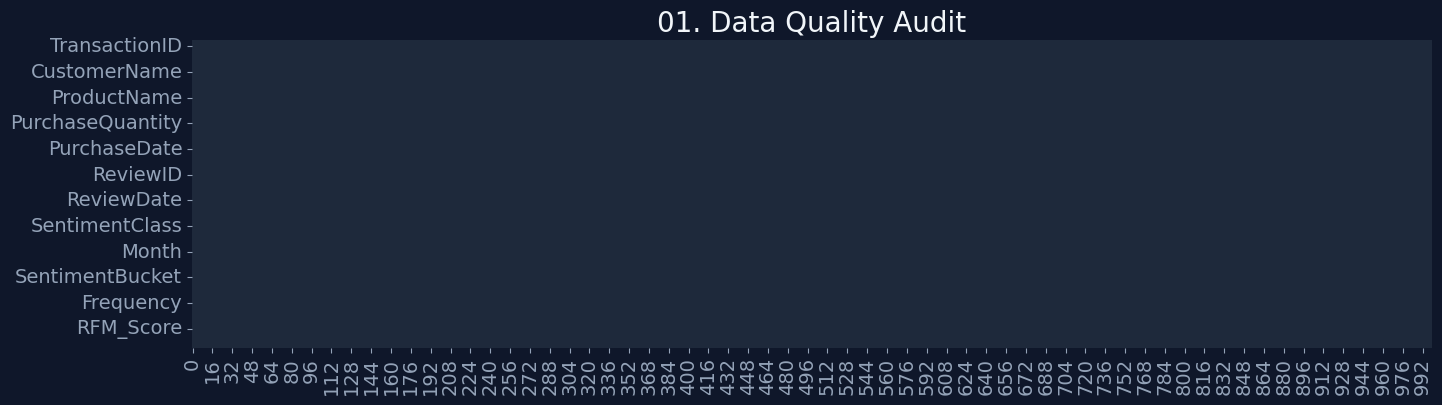

In [4]:
plt.figure(figsize=(16, 4))
sns.heatmap(df.isnull().T, cmap=['#1e293b', '#ef4444'], cbar=False)
plt.title('01. Data Quality Audit')
plt.savefig('plots/01_missing_data_audit.png')
plt.show()


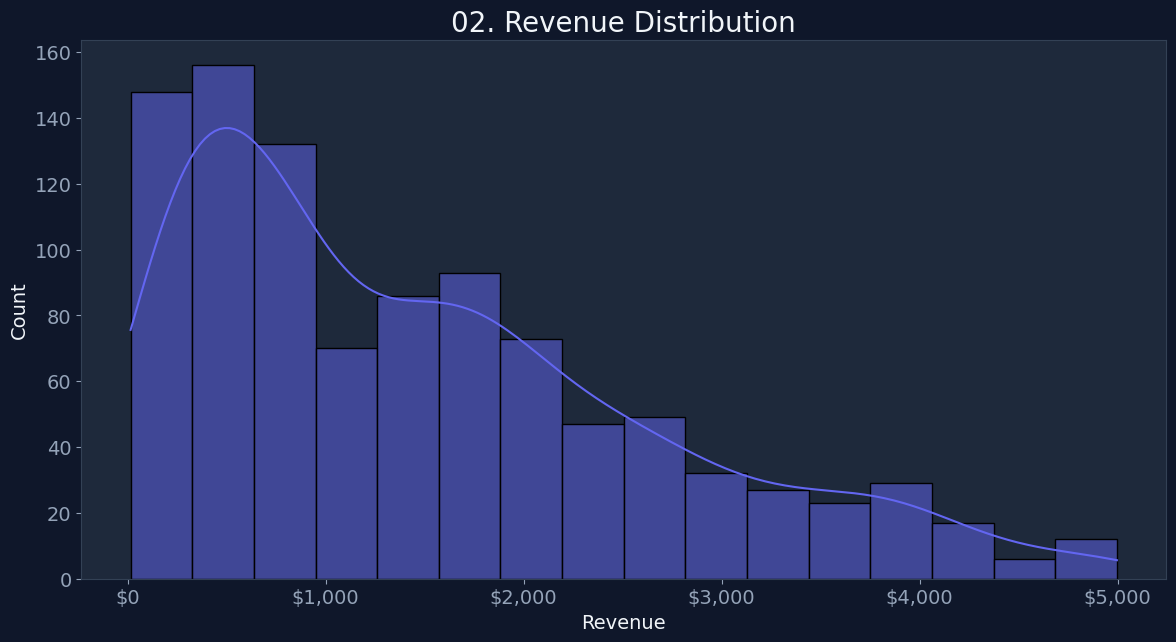

In [5]:
plt.figure(figsize=(14, 7))
sns.histplot(df['Revenue'], kde=True, color='#6366f1')
plt.title('02. Revenue Distribution')
plt.gca().xaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))
plt.savefig('plots/02_revenue_distribution.png')
plt.show()


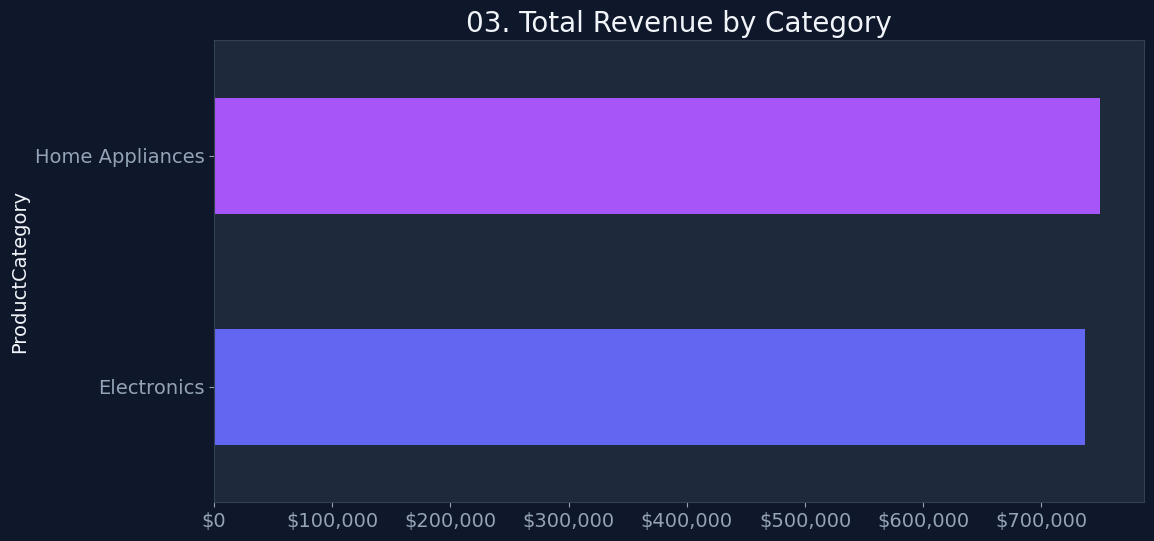

In [6]:
plt.figure(figsize=(12, 6))
df.groupby('ProductCategory')['Revenue'].sum().sort_values().plot(kind='barh', color=PALETTE_MAIN)
plt.title('03. Total Revenue by Category')
plt.gca().xaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))
plt.savefig('plots/03_revenue_by_category.png')
plt.show()


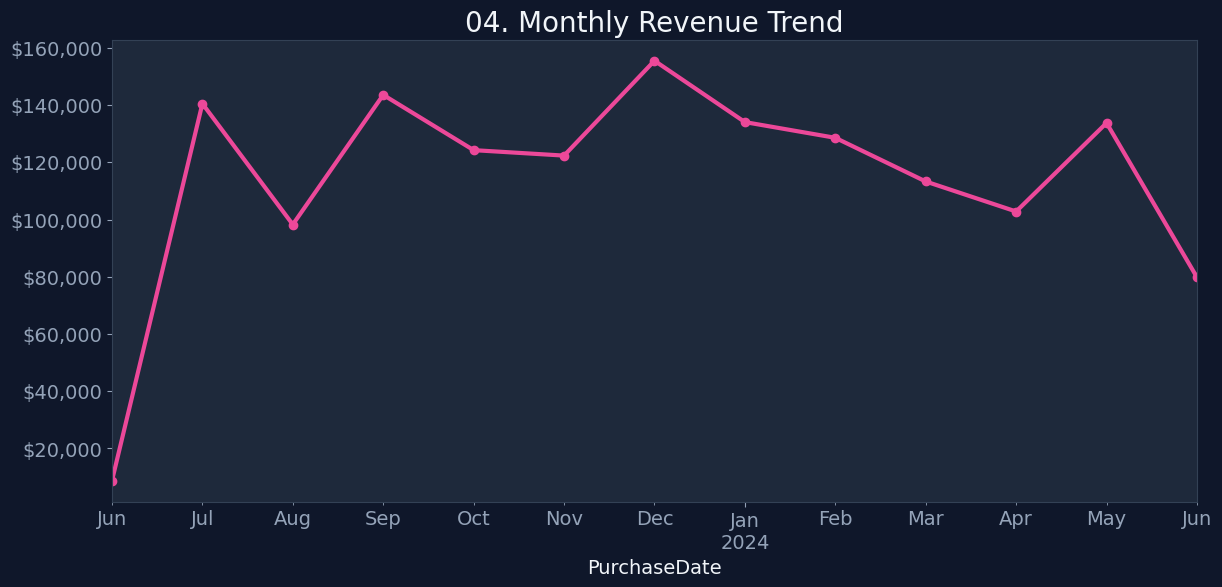

In [7]:
plt.figure(figsize=(14, 6))
df.groupby(df['PurchaseDate'].dt.to_period('M'))['Revenue'].sum().plot(marker='o', color='#ec4899', linewidth=3)
plt.title('04. Monthly Revenue Trend')
plt.gca().yaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))
plt.savefig('plots/04_monthly_revenue_trend.png')
plt.show()


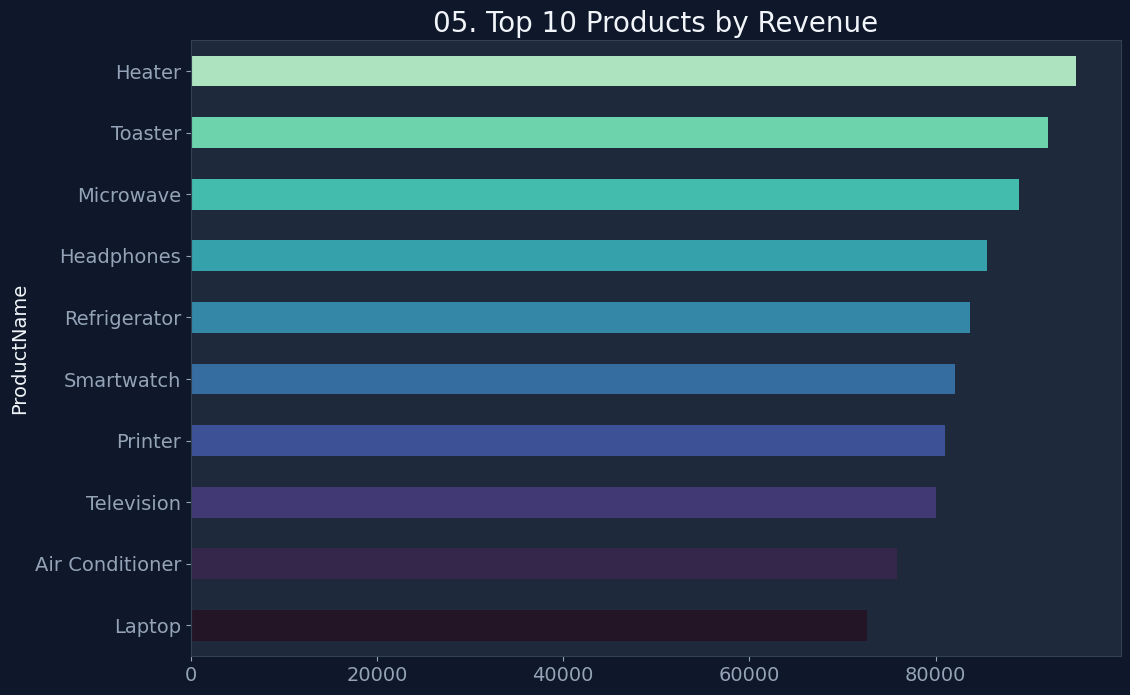

In [8]:
plt.figure(figsize=(12, 8))
df.groupby('ProductName')['Revenue'].sum().nlargest(10).sort_values().plot(kind='barh', color=sns.color_palette('mako', 10))
plt.title('05. Top 10 Products by Revenue')
plt.savefig('plots/05_top_products.png')
plt.show()


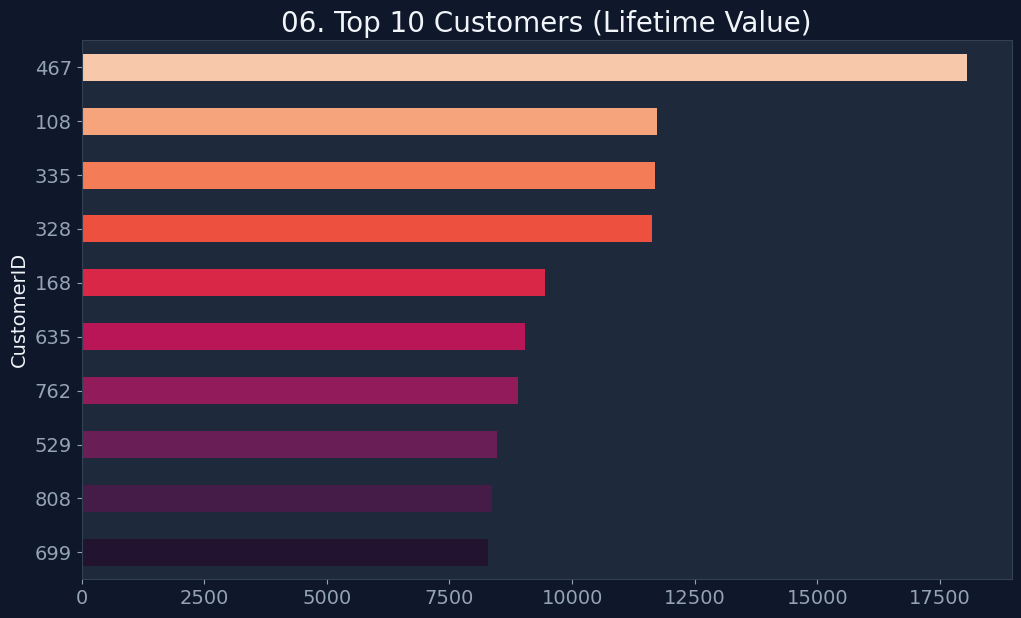

In [9]:
plt.figure(figsize=(12, 7))
df.groupby('CustomerID')['Revenue'].sum().nlargest(10).sort_values().plot(kind='barh', color=sns.color_palette('rocket', 10))
plt.title('06. Top 10 Customers (Lifetime Value)')
plt.savefig('plots/06_top_customers.png')
plt.show()


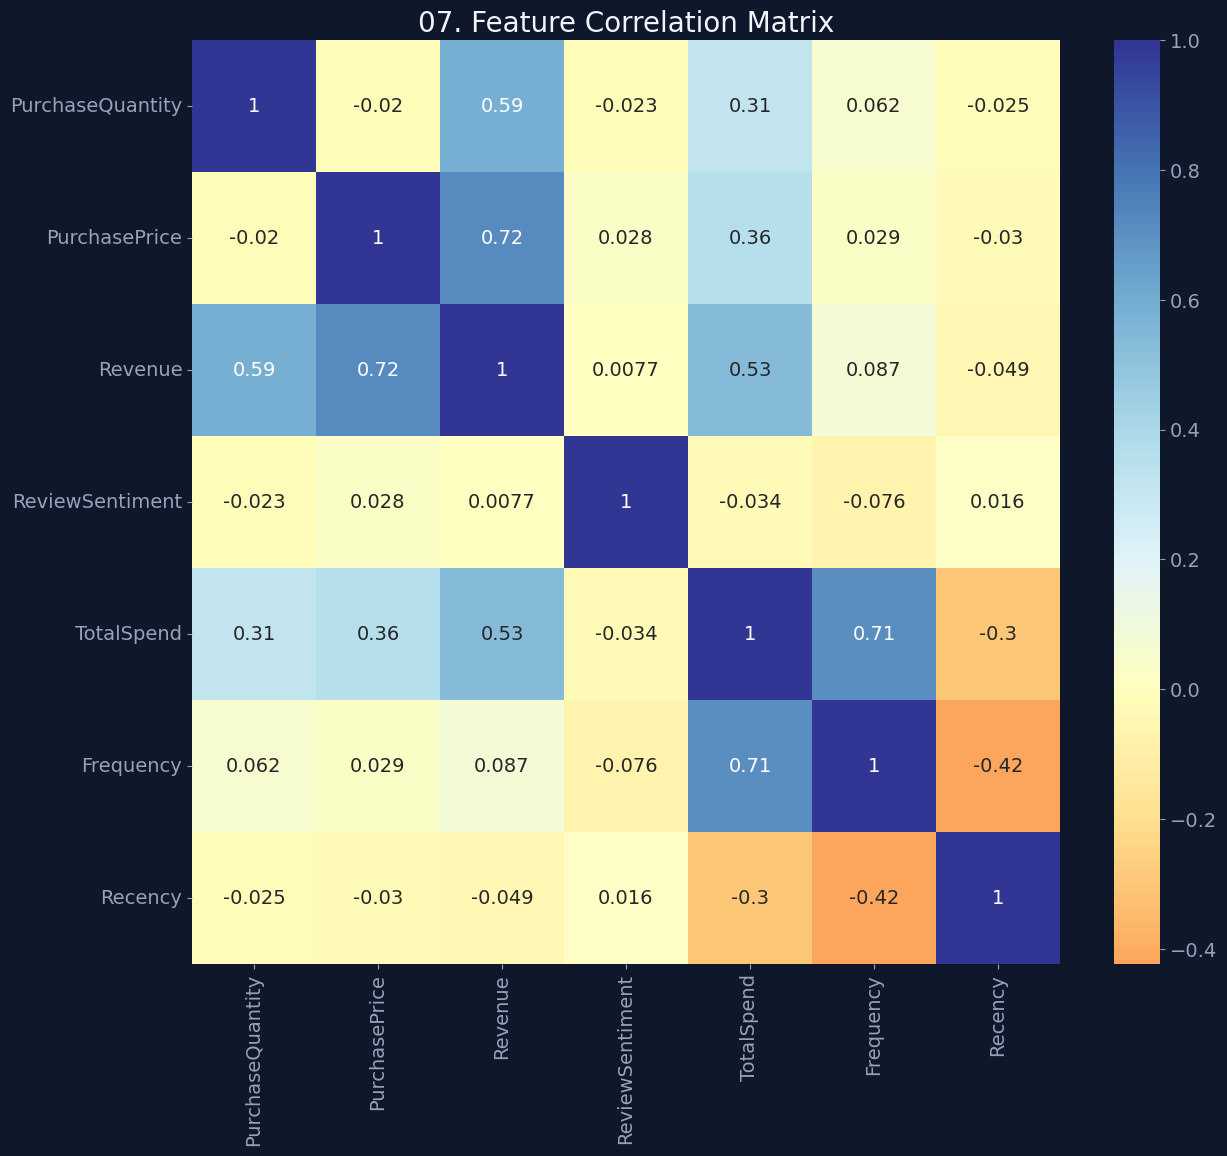

In [10]:
plt.figure(figsize=(14, 12))
sns.heatmap(df[['PurchaseQuantity', 'PurchasePrice', 'Revenue', 'ReviewSentiment', 'TotalSpend', 'Frequency', 'Recency']].corr(), annot=True, cmap='RdYlBu', center=0)
plt.title('07. Feature Correlation Matrix')
plt.savefig('plots/07_correlation_heatmap.png')
plt.show()


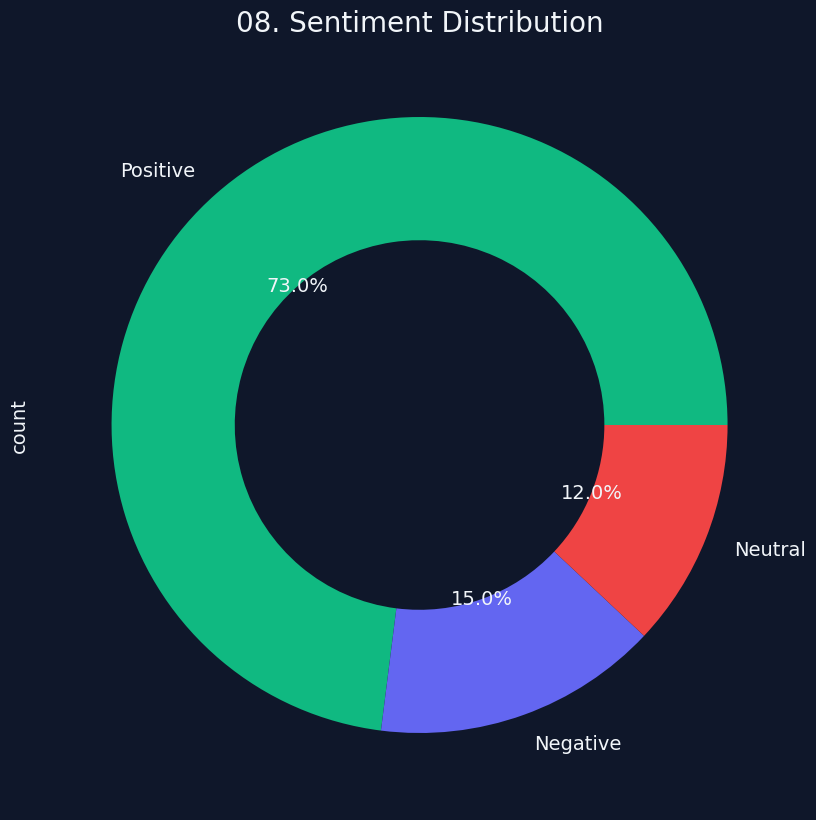

In [11]:
fig, ax = plt.subplots(figsize=(10, 10))
df['SentimentClass'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=PALETTE_SENTIMENT, wedgeprops=dict(width=0.4))
plt.title('08. Sentiment Distribution')
plt.savefig('plots/08_sentiment_distribution.png')
plt.show()


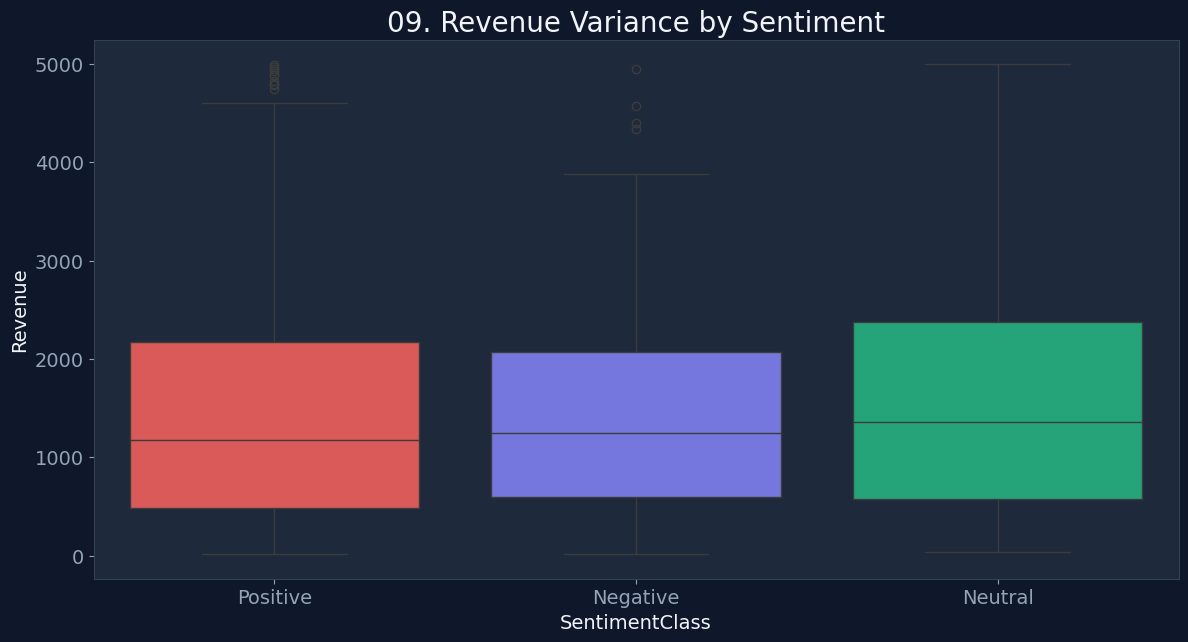

In [12]:
plt.figure(figsize=(14, 7))
sns.boxplot(data=df, x='SentimentClass', y='Revenue', palette=PALETTE_SENTIMENT[::-1])
plt.title('09. Revenue Variance by Sentiment')
plt.savefig('plots/09_sentiment_vs_revenue.png')
plt.show()


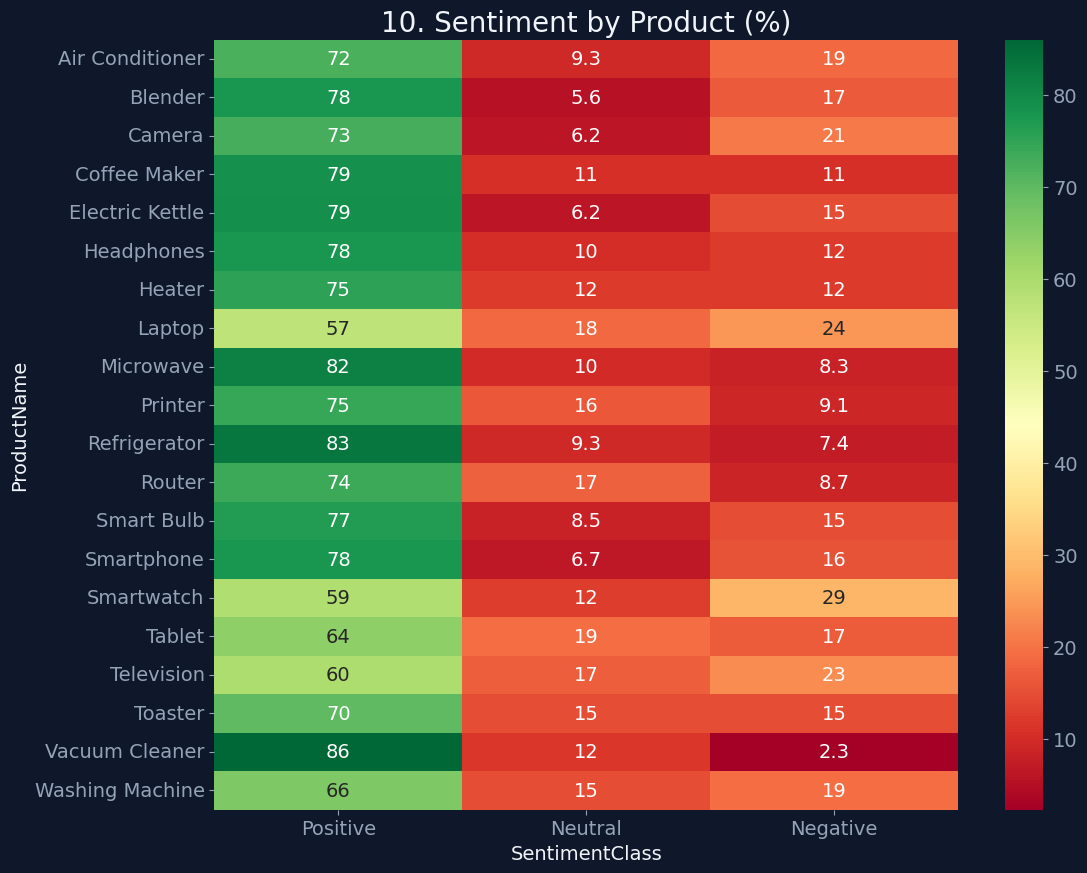

In [13]:
cross = pd.crosstab(df['ProductName'], df['SentimentClass'], normalize='index') * 100
plt.figure(figsize=(12, 10))
sns.heatmap(cross.reindex(columns=['Positive', 'Neutral', 'Negative'], fill_value=0), annot=True, cmap='RdYlGn')
plt.title('10. Sentiment by Product (%)')
plt.savefig('plots/10_product_sentiment.png')
plt.show()


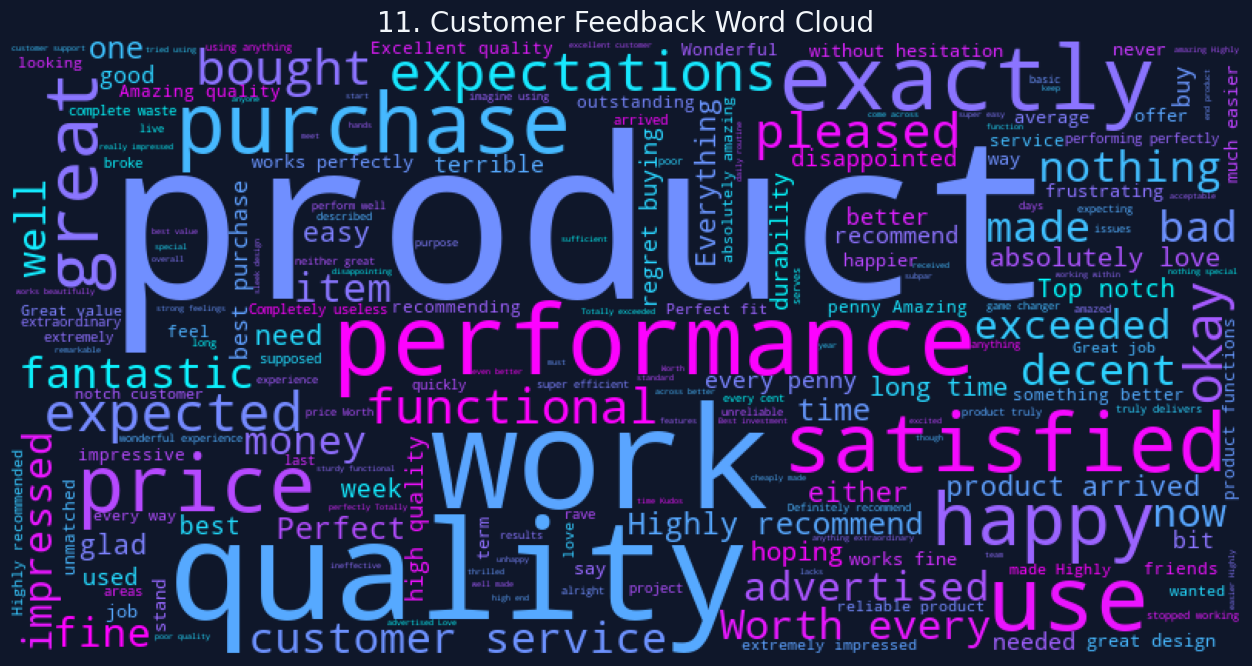

In [14]:
wc = WordCloud(width=800, height=400, background_color='#0f172a', colormap='cool').generate(' '.join(df['ReviewText'].astype(str)))
plt.figure(figsize=(16, 8))
plt.imshow(wc)
plt.title('11. Customer Feedback Word Cloud')
plt.axis('off')
plt.savefig('plots/11_wordcloud.png')
plt.show()


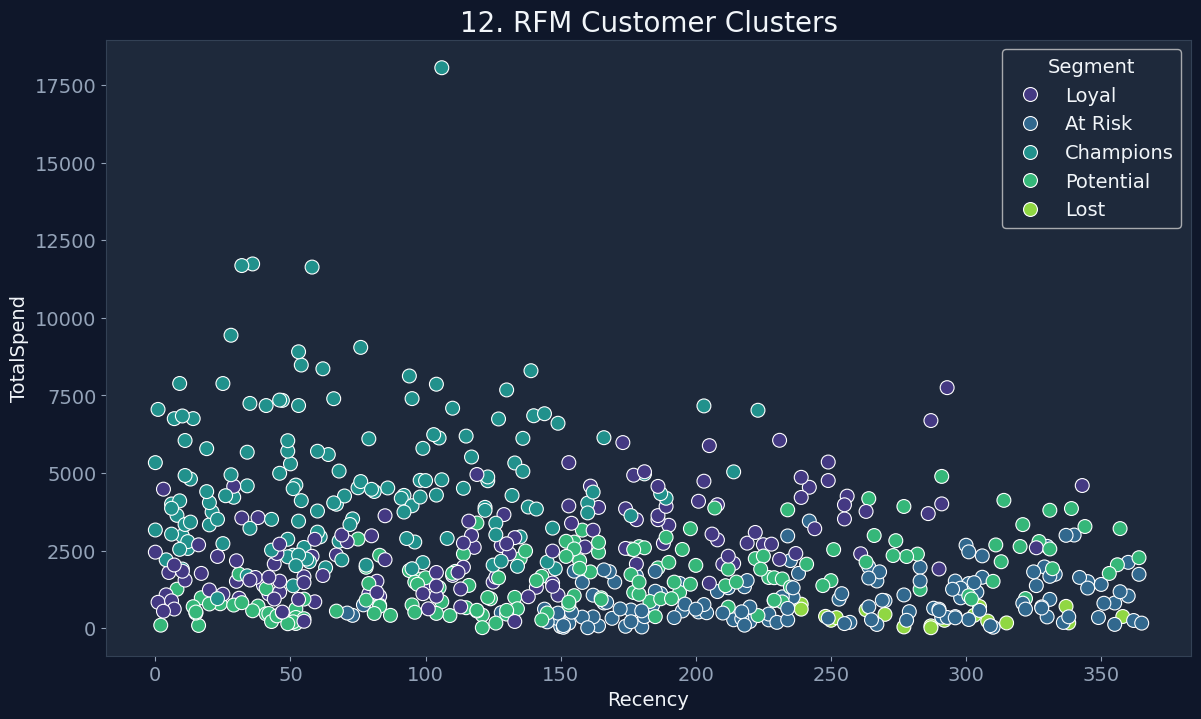

In [15]:
plt.figure(figsize=(14, 8))
sns.scatterplot(data=rfm, x='Recency', y='TotalSpend', hue='Segment', palette='viridis', s=100)
plt.title('12. RFM Customer Clusters')
plt.savefig('plots/12_rfm_clusters.png')
plt.show()


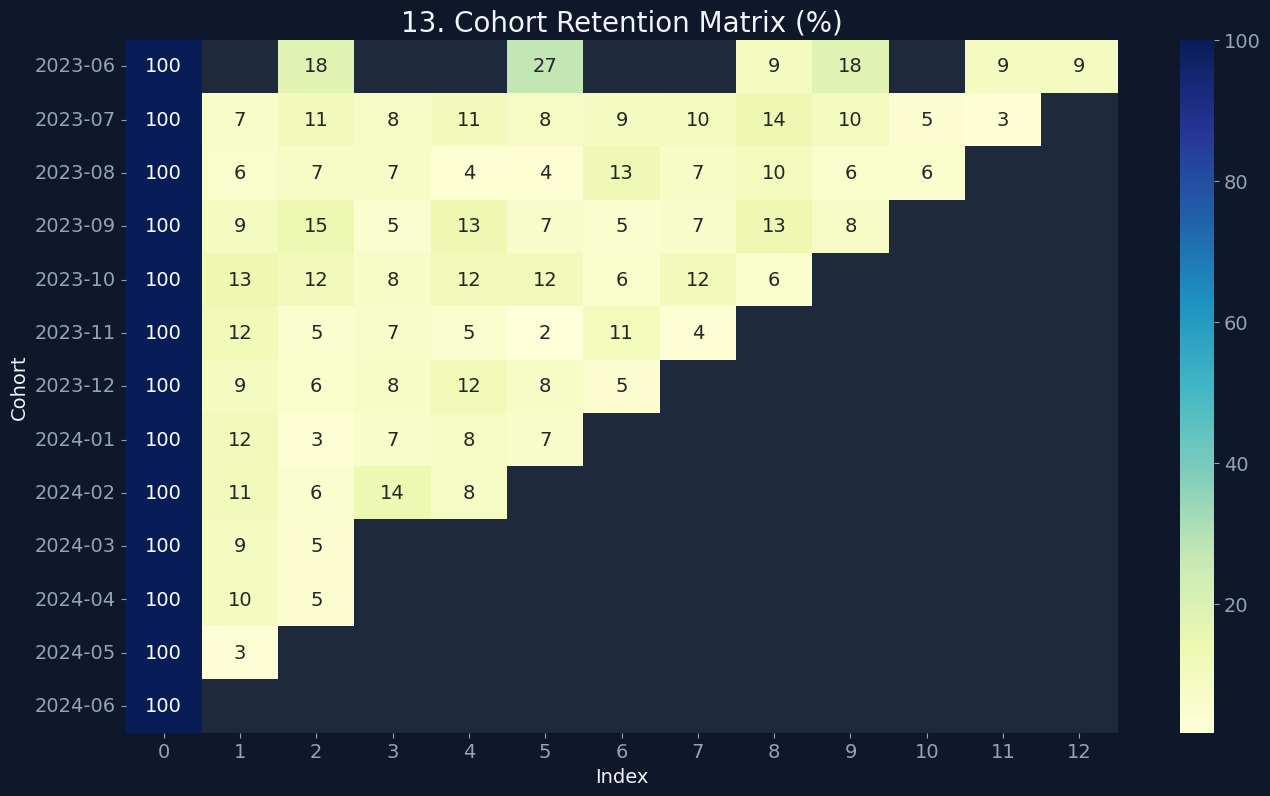

In [16]:
df['Cohort'] = df.groupby('CustomerID')['PurchaseDate'].transform('min').dt.to_period('M')
df['TxMonth'] = df['PurchaseDate'].dt.to_period('M')
df['Index'] = (df['TxMonth'] - df['Cohort']).apply(lambda x: x.n)
ret = df.groupby(['Cohort', 'Index'])['CustomerID'].nunique().unstack().divide(df.groupby('Cohort')['CustomerID'].nunique(), axis=0) * 100
plt.figure(figsize=(16, 9))
sns.heatmap(ret, annot=True, fmt='.0f', cmap='YlGnBu')
plt.title('13. Cohort Retention Matrix (%)')
plt.savefig('plots/13_retention_matrix.png')
plt.show()


In [17]:
np.random.seed(42)
df['Subscription'] = np.random.choice([0, 1], size=len(df), p=[0.7, 0.3])
X = df[['PurchaseQuantity', 'PurchasePrice', 'Revenue', 'ReviewSentiment', 'TotalSpend', 'Frequency', 'Recency']].fillna(0)
y = df['Subscription']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_train, y_train)


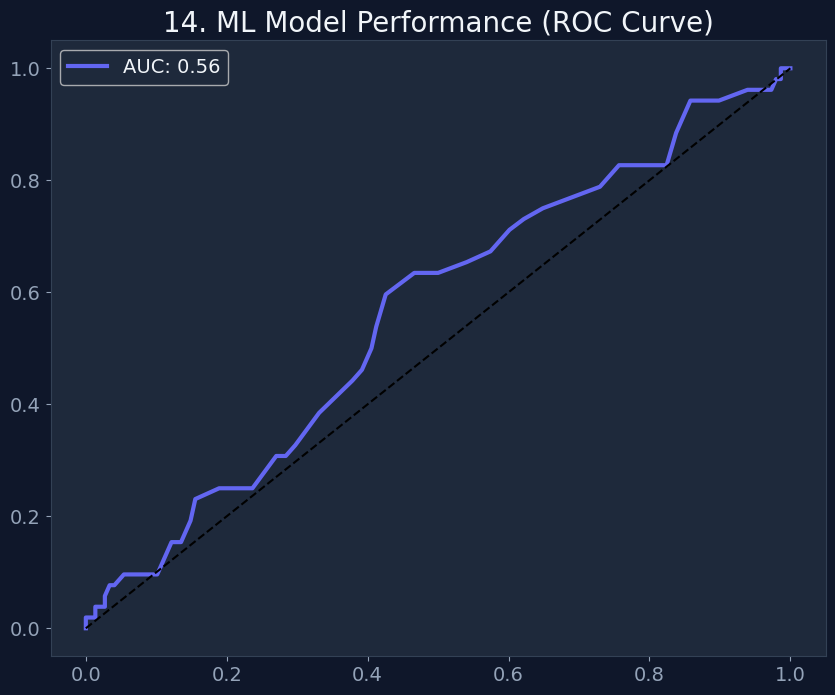

In [18]:
fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_test)[:,1])
plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='#6366f1', lw=3, label=f'AUC: {roc_auc_score(y_test, model.predict_proba(X_test)[:,1]):.2f}')
plt.plot([0,1], [0,1], 'k--')
plt.title('14. ML Model Performance (ROC Curve)')
plt.legend()
plt.savefig('plots/14_roc_curve.png')
plt.show()


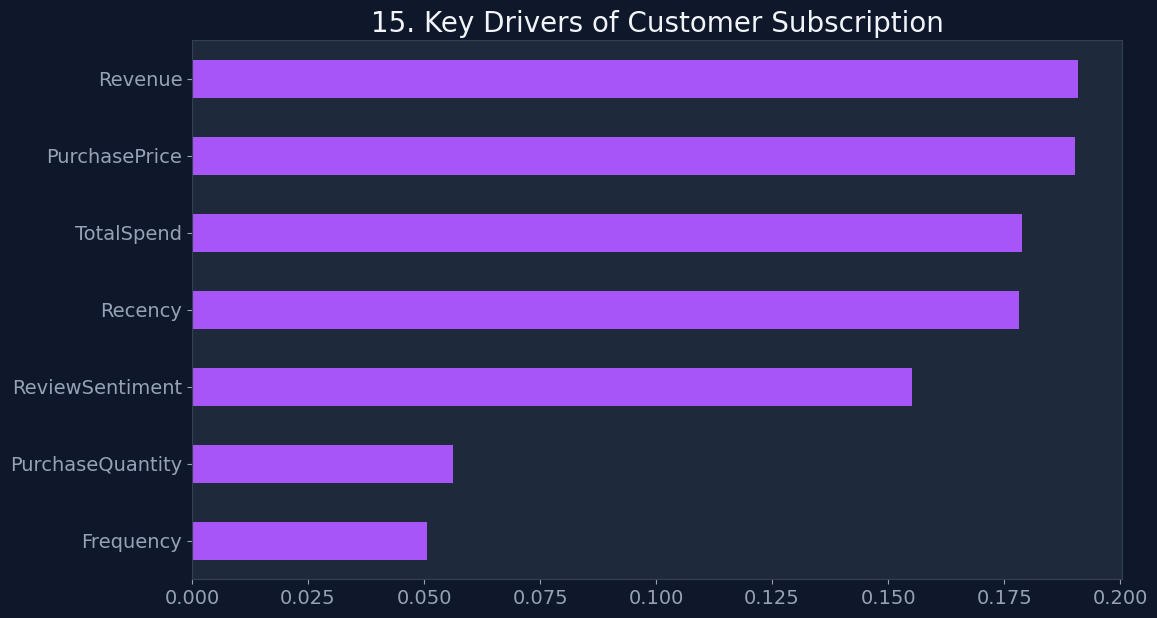

In [19]:
plt.figure(figsize=(12, 7))
pd.Series(model.feature_importances_, index=X.columns).sort_values().plot(kind='barh', color='#a855f7')
plt.title('15. Key Drivers of Customer Subscription')
plt.savefig('plots/15_feature_importance.png')
plt.show()


In [20]:
df.to_csv('data/powerbi_advanced_export.csv', index=False); print('✅ Exported.')

✅ Exported.
